Shape: (32581, 12)
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y            

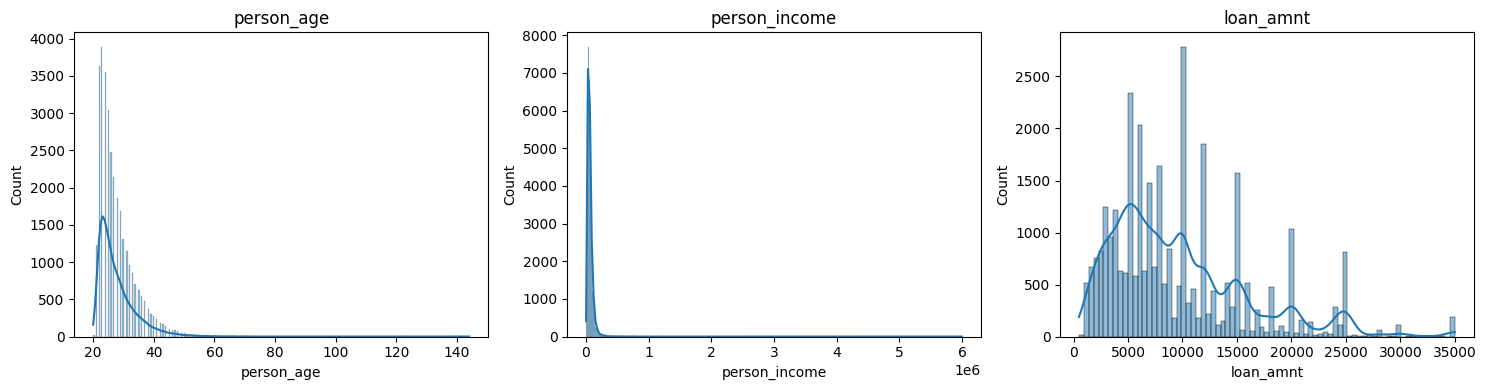

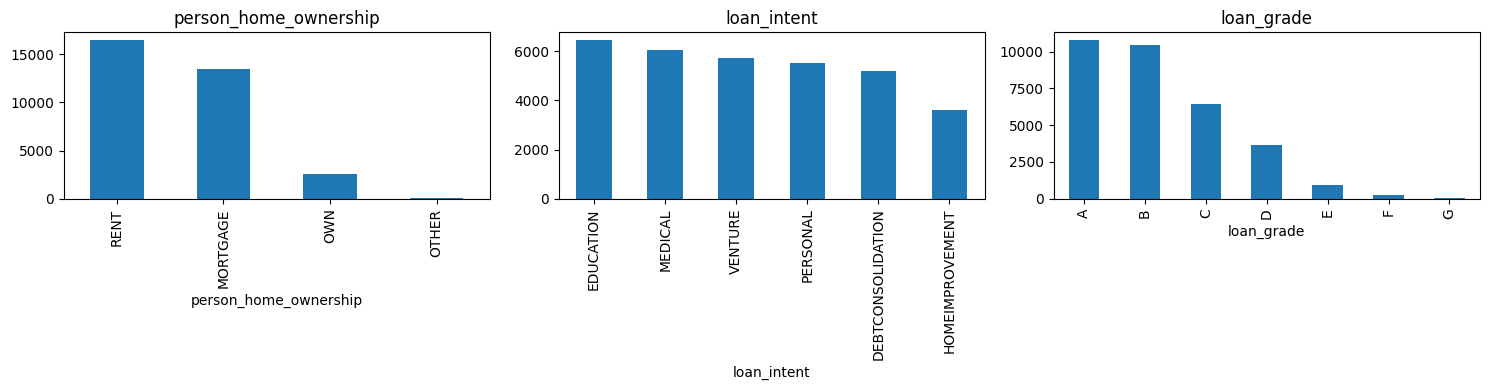

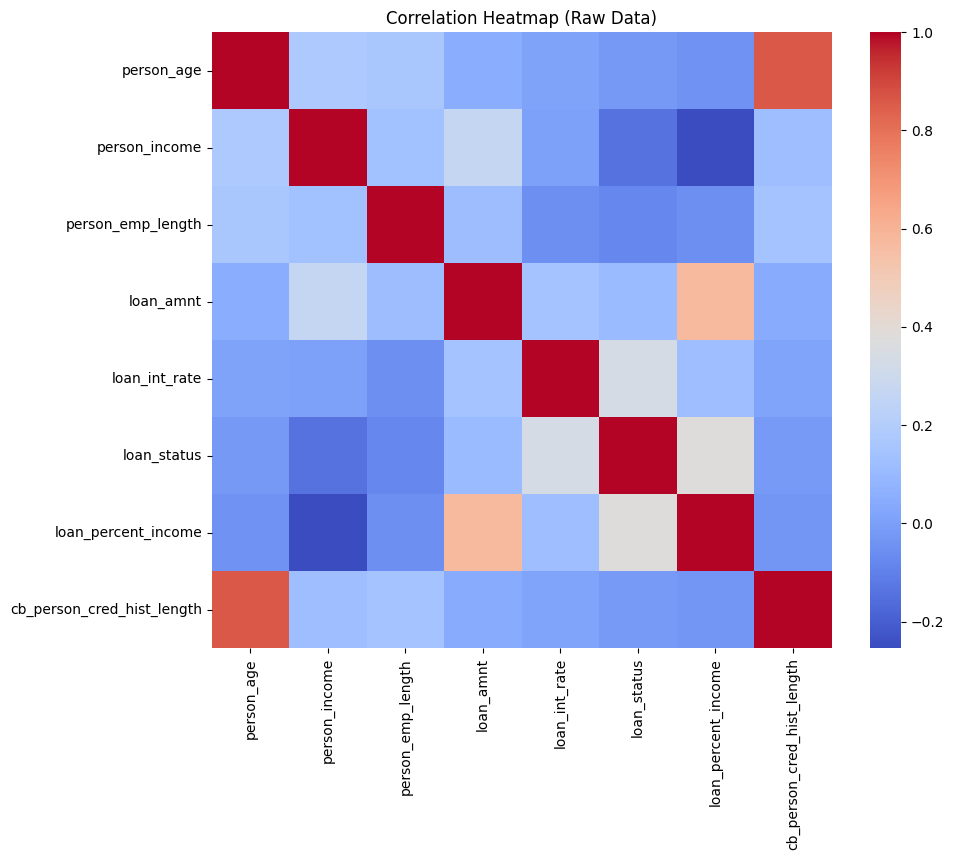

In [1]:
# =========================================
# 01 — EXPLORATORY DATA ANALYSIS
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATA
df = pd.read_csv('../data/raw/raw_data.csv')

print("Shape:", df.shape)
print(df.head())

# BASIC INFO
df.info()
df.describe()

# MISSING VALUES
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

print(pd.DataFrame({'Missing': missing, 'Missing %': pct}))

# NUMERICAL DISTRIBUTIONS
num_cols = ['person_age', 'person_income', 'loan_amnt']

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# CATEGORICAL DISTRIBUTIONS
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade']

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# CORRELATION HEATMAP (RAW)
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (Raw Data)")
plt.show()